In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:
os.chdir('..')

In [3]:
STOCK = 'ETH'
TF = '1h'
LEVEL = 2
PRICE = 'close'
SEQ_LENGTH = 48
SEQ_LENGTH_MACD = 28
BATCH_SIZE = 8
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)
DATA_TYPE = 'float32'
FILE_NAME = f'cnn/{STOCK}_{TF}/figs'

In [4]:
from utils.utils import CreateTimeFrames

In [5]:
df = pd.read_csv(f'data/{STOCK}USD_2023_2024.csv',
                  index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})


timeframes = [TF]
# timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)
df_tf = df[TF]
df_tf = df_tf.iloc[-4050:,:]

# Backtester

In [6]:
os.getcwd()
# from utils.backtester import MACDBacktester

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src'

# Market strategy pattern

In [7]:
df_all = pd.read_csv(f'strategy/files/df_all_{STOCK}_{TF}.csv')

In [8]:
import numpy as np
import pandas as pd

class MACDBacktester:
    def __init__(self, data: pd.DataFrame, price: str = 'close', sell_fee: float = 0.115,
                 buy_fee: float = 0.115, initial_capital: float = 100):
        """
        It works as a trade analyzer with a specific amount of money and trading cost.
        
        :param data: DataFrame containing different features ('macd_line', 'signal_line', price = 'close', 'y_xlstm').
        :param price: For trading (default: 'close').
        :param sell_fee: Sell trading cost in percentage (default: 0.115).
        :param buy_fee: Buy trading cost in percentage (default: 0.115).
        :param initial_capital: Initial capital.
        """
        self.data = data.copy()
        self.real_price = price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0

    def generate_signals(self):
        """
        Generates trading signals based on the MACD-XLSTM strategy.
        """
        buy_signals = (self.data['macd_line'] > self.data['signal_line']) & \
                      (self.data['macd_line'].shift(1) <= self.data['signal_line'].shift(1)) #& \
                     # (self.data['y_xlstm'] > self.data['close'])
        sell_signals = (self.data['macd_line'] < self.data['signal_line']) & \
                       (self.data['macd_line'].shift(1) >= self.data['signal_line'].shift(1)) #& \
                     #  (self.data['y_xlstm'] < self.data['close'])
        
        raw_signals = np.zeros(len(self.data), dtype=np.int8)
        holding_position = False

        for i in range(len(self.data)):
            if buy_signals.iloc[i] and not holding_position:
                raw_signals[i] = 1
                holding_position = True
            elif sell_signals.iloc[i] and holding_position:
                raw_signals[i] = -1
                holding_position = False

        # Adjust the signals:
        # 1. If the first nonzero signal is a sell, remove it.
        trade_idx = np.where(raw_signals != 0)[0]
        if len(trade_idx) > 0 and raw_signals[trade_idx[0]] == -1:
            raw_signals[trade_idx[0]] = 0

        # 2. If the last signal is a buy, force a sell at the end.
        if len(trade_idx) > 0 and raw_signals[trade_idx[-1]] == 1:
            raw_signals[-1] = -1

        # Save the raw signals in a dedicated column.
        self.data['signals_macd_xlstm'] = raw_signals

        positions = np.zeros(len(self.data), dtype=np.int8)
        current_position = 0
        for i, signal in enumerate(raw_signals):
            if signal == 1:
                current_position = 1
            elif signal == -1:
                current_position = 0
            positions[i] = current_position
        self.data['positions'] = positions
        return self.data

    def backtest_strategy(self):
        """ Backtests the trading strategy. """
        self.data = self.data.copy()
        self.data['price'] = self.data[self.real_price]
        self.data['positions_diff'] = self.data['positions'].diff().fillna(0)
        
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital

        cash = self.initial_capital
        holdings = 0.0
        position = False
        buy_price = 0.0
        win_count = 0
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']

            if position_change == 1 and not position:  # Enter long position
                holdings = cash * (1 - self.buy_fee_percent) / price
                cash = 0
                position = True
                buy_price = price

            elif position_change == -1 and position: # Exit long position
                cash = holdings * price * (1 - self.sell_fee_percent)
                holdings = 0
                position = False
                trade_return = ((price - buy_price) / buy_price) * 100
                self.trades.append(trade_return)
                total_trades += 1
                if trade_return > 0:
                    win_count += 1

            total = cash + (holdings * price if position else 0)
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = float(holdings * price if position else 0)
            self.data.at[idx, 'total'] = float(total)

        self.results = self.data[['cash', 'holdings', 'total']]
        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data, self.trades

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        (Implementation remains unchanged.)
        """
        if not hasattr(self, 'results'):
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 365 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(365) * 100

        periods_per_year = 8760
        annual_rf_rate = 0.04  
        daily_rf_rate = annual_rf_rate / 365  
        hourly_rf_rate = daily_rf_rate / 24  

        excess_returns = returns - hourly_rf_rate
        mean_hourly_excess = excess_returns.mean()
        std_hourly = returns.std()  
        sharpe_ratio = (mean_hourly_excess / std_hourly) * np.sqrt(periods_per_year) if std_hourly != 0 else np.nan

        target_return = hourly_rf_rate  
        downside_returns = returns.copy()
        downside_returns[downside_returns > target_return] = 0
        std_downside = downside_returns.std()
        annualized_downside_deviation = std_downside * np.sqrt(periods_per_year)
        annualized_excess_return = mean_hourly_excess * periods_per_year
        sortino_ratio = annualized_excess_return / annualized_downside_deviation if annualized_downside_deviation != 0 else np.nan

        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Sortino Ratio': sortino_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)': self.win_rate
        }
        return metrics, self.results


    def print_trades(self):
        """ Prints individual trade returns. """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = np.sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")
        return self.trades



In [9]:
df_all_backtest = df_all.iloc[-805:,:].reset_index(drop=True)

In [10]:
backtester = MACDBacktester(df_all_backtest, price='close', initial_capital=df_all_backtest['close'][0])
backtester.generate_signals()
backtester.backtest_strategy()
metrics, results = backtester.get_performance_metrics()
print(metrics)
trades = backtester.print_trades()

C:\Users\arvin\AppData\Local\Temp\ipykernel_6516\3311999176.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2347.2975' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = float(total)
C:\Users\arvin\AppData\Local\Temp\ipykernel_6516\3311999176.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2373.5314462275' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'cash'] = float(cash)


{'Total Return (%)': 29.74070327454712, 'Annualized Return (%)': 12.860320509941946, 'Annualized Volatility (%)': 7.654650421975652, 'Sharpe Ratio': 7.637390726556092, 'Sortino Ratio': 12.878670146168943, 'Max Drawdown (%)': 7.833452914776124, 'Win Rate (%)': 63.63636363636363}
Trade 1: Return = 1.23%
Trade 2: Return = 2.10%
Trade 3: Return = -0.08%
Trade 4: Return = 0.17%
Trade 5: Return = 0.04%
Trade 6: Return = 0.46%
Trade 7: Return = 0.87%
Trade 8: Return = 3.65%
Trade 9: Return = 1.63%
Trade 10: Return = -0.33%
Trade 11: Return = -0.29%
Trade 12: Return = -0.45%
Trade 13: Return = -0.12%
Trade 14: Return = 0.16%
Trade 15: Return = -0.61%
Trade 16: Return = 0.00%
Trade 17: Return = 1.31%
Trade 18: Return = -0.67%
Trade 19: Return = 2.29%
Trade 20: Return = 1.45%
Trade 21: Return = -0.08%
Trade 22: Return = 1.15%
Trade 23: Return = 0.53%
Trade 24: Return = -0.28%
Trade 25: Return = 0.86%
Trade 26: Return = 2.98%
Trade 27: Return = 3.63%
Trade 28: Return = -0.88%
Trade 29: Return = -

In [11]:
sum  = np.sum(trades)
sum

44.450383484451166

In [12]:
results

,cash,holdings,total
0,2350.000000,0.00000,2350.000000
1,0.000000,2347.29750,2347.297500
2,0.000000,2342.30325,2342.303250
3,0.000000,2312.33775,2312.337750
4,0.000000,2335.31130,2335.311300
...,...,...,...
800,3048.906527,0.00000,3048.906527
801,3048.906527,0.00000,3048.906527
802,3048.906527,0.00000,3048.906527
803,3048.906527,0.00000,3048.906527


In [13]:
results.iloc[282:293,:]

,cash,holdings,total
282,2732.767630,0.000000,2732.767630
283,0.000000,2729.624947,2729.624947
284,0.000000,2736.954205,2736.954205
285,0.000000,2738.001242,2738.001242
286,0.000000,2730.671984,2730.671984
287,0.000000,2733.813094,2733.813094
288,2702.431726,0.000000,2702.431726
289,2702.431726,0.000000,2702.431726
290,0.000000,2699.323930,2699.323930
291,2592.169265,0.000000,2592.169265


In [14]:
df_all_backtest.loc[282:293,'close']


282    2593
283    2607
284    2614
285    2615
286    2608
287    2611
288    2584
289    2600
290    2669
291    2566
292    2572
293    2591
Name: close, dtype: int64

In [15]:
tot = results['total'].diff()
tot_cum = tot.cumsum()

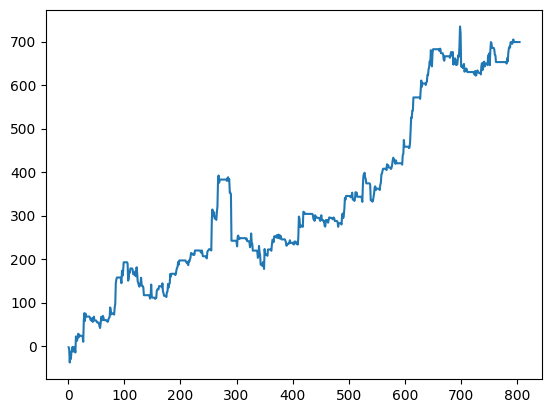

In [16]:
plt.plot(tot_cum)

# Market Strategy

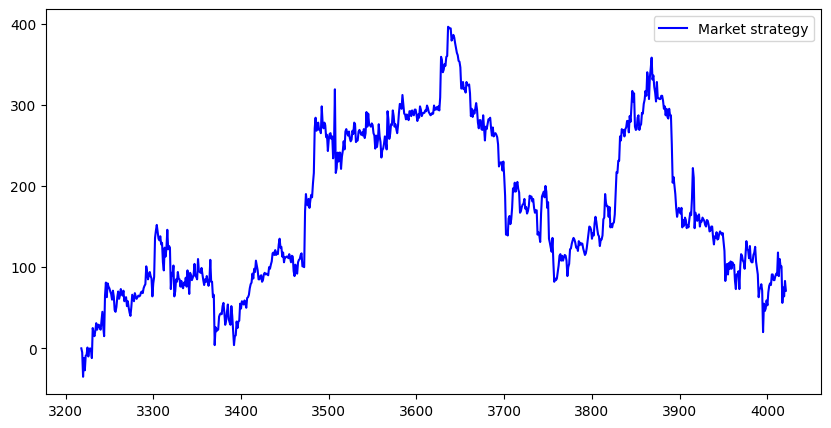

In [17]:
trade_df = pd.DataFrame({'close':df_all['close'], 'open':df_all['open']})
trade_df = trade_df.astype({
    'close': np.int32,
    'open': np.int32
})

trade_df = trade_df.iloc[-805:,:]

trade_df['tomorrows_returns'] = 0
trade_df['tomorrows_returns'] = trade_df['close'] - trade_df['close'].shift(1)
trade_df['tomorrows_returns'] = trade_df['tomorrows_returns'].shift(-1)
# trade_df.head()

trade_df.loc[:, 'cumulative_market_return'] = np.cumsum(trade_df['tomorrows_returns'])

fig, ax =plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['cumulative_market_return'], color='blue', label='Market strategy')
ax.legend()
plt.show()

In [18]:
trade_df

,close,open,tomorrows_returns,cumulative_market_return
3218,2350,2366,0.0,0.0
3219,2350,2350,-5.0,-5.0
3220,2345,2350,-30.0,-35.0
3221,2315,2345,23.0,-12.0
3222,2338,2315,-15.0,-27.0
...,...,...,...,...
4018,2406,2451,19.0,75.0
4019,2425,2407,-11.0,64.0
4020,2414,2425,19.0,83.0
4021,2433,2411,-12.0,71.0


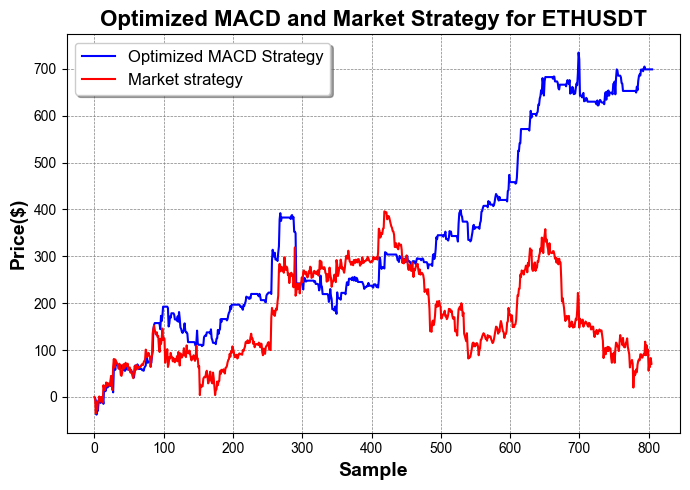

In [19]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

b = len(tot_cum)
t = np.linspace(0, b, b)

fig, axes = plt.subplots(1,1, figsize=(7,5))

axes.plot(t, tot_cum, color='blue', label='Optimized MACD Strategy')
axes.plot(t, trade_df['cumulative_market_return'], color='red', label='Market strategy')

axes.set_xlabel("Sample", fontsize=14, fontweight='bold')
axes.set_ylabel("Price($)", fontsize=14, fontweight='bold')
axes.set_title(f'Optimized MACD and Market Strategy for {STOCK}USDT', fontsize=16, fontweight='bold')

axes.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axes.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)

axes.spines['right'].set_visible(True)
axes.spines['bottom'].set_visible(True)
axes.spines['left'].set_visible(True)

plt.tight_layout()
plt.savefig(f'strategy/figs/MACD_MARKET_{STOCK}{TF}.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src'

# XLSTM

In [21]:
y_train_xlstm = np.load(f'data/xLSTM/{STOCK}/train_predictions.npy')
y_val_xlstm = np.load(f'data/xLSTM/{STOCK}/val_predictions.npy')
y_test_xlstm = np.load(f'data/xLSTM/{STOCK}/test_predictions.npy')

print(f'y_train_xlstm.shape is: {y_train_xlstm.shape}')
print(f'y_val_xlstm.shape is: {y_val_xlstm.shape}')
print(f'y_test_xlstm.shape is: {y_test_xlstm.shape}')

y_xlstm = np.vstack((y_train_xlstm, y_val_xlstm, y_test_xlstm))
print(f'y_xlstm.shape is: {y_xlstm.shape}')

y_train_xlstm.shape is: (4166, 48, 1)
y_val_xlstm.shape is: (595, 48, 1)
y_test_xlstm.shape is: (1191, 48, 1)
y_xlstm.shape is: (5952, 48, 1)


In [22]:
y_xlstm = y_xlstm[:,-1,:].squeeze()

In [23]:
if STOCK=='ETH':
    y_xlstm = y_xlstm[-4024:]


In [24]:
y_xlstm = y_xlstm[-805:]
y_xlstm = np.roll(y_xlstm, -1)

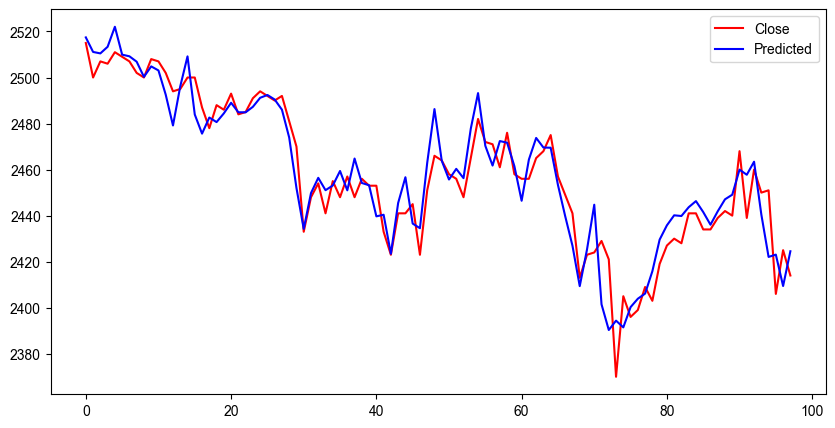

In [25]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(trade_df['close'][-100:-2].to_numpy(), color='red', label='Close')
ax.plot(y_xlstm[-100:-2], color='blue', label='Predicted')
plt.legend()


## Modified backterster

In [26]:
import numpy as np
import pandas as pd

class xLSTM_MACD_Backtester:
    def __init__(self, data: pd.DataFrame, price: str = 'close', sell_fee: float = 0.115,
                 buy_fee: float = 0.115, initial_capital: float = 100):
        """
        It works as a trade analyzer with a specific amount of money and trading cost.
        
        :param data: DataFrame containing different features ('macd_line', 'signal_line', price = 'close', 'y_xlstm').
        :param price: For trading (default: 'close').
        :param sell_fee: Sell trading cost in percentage (default: 0.115).
        :param buy_fee: Buy trading cost in percentage (default: 0.115).
        :param initial_capital: Initial capital.
        """
        self.data = data.copy()
        self.real_price = price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0

    def generate_signals(self):
        """
        Generates trading signals based on the MACD-XLSTM strategy.
        """
        buy_signals = (self.data['macd_line'] > self.data['signal_line']) & \
                      (self.data['macd_line'].shift(1) <= self.data['signal_line'].shift(1)) & \
                      (self.data['y_xlstm'] > self.data['close'])
        sell_signals = (self.data['macd_line'] < self.data['signal_line']) & \
                       (self.data['macd_line'].shift(1) >= self.data['signal_line'].shift(1)) & \
                       (self.data['y_xlstm'] < self.data['close'])
        
        raw_signals = np.zeros(len(self.data), dtype=np.int8)
        holding_position = False

        for i in range(len(self.data)):
            if buy_signals.iloc[i] and not holding_position:
                raw_signals[i] = 1
                holding_position = True
            elif sell_signals.iloc[i] and holding_position:
                raw_signals[i] = -1
                holding_position = False

        # Adjust the signals:
        # 1. If the first nonzero signal is a sell, remove it.
        trade_idx = np.where(raw_signals != 0)[0]
        if len(trade_idx) > 0 and raw_signals[trade_idx[0]] == -1:
            raw_signals[trade_idx[0]] = 0

        # 2. If the last signal is a buy, force a sell at the end.
        if len(trade_idx) > 0 and raw_signals[trade_idx[-1]] == 1:
            raw_signals[-1] = -1

        # Save the raw signals in a dedicated column.
        self.data['signals_macd_xlstm'] = raw_signals

        positions = np.zeros(len(self.data), dtype=np.int8)
        current_position = 0
        for i, signal in enumerate(raw_signals):
            if signal == 1:
                current_position = 1
            elif signal == -1:
                current_position = 0
            positions[i] = current_position
        self.data['positions'] = positions
        return self.data

    def backtest_strategy(self):
        """ Backtests the trading strategy. """
        self.data = self.data.copy()
        self.data['price'] = self.data[self.real_price]
        self.data['positions_diff'] = self.data['positions'].diff().fillna(0)
        
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital

        cash = self.initial_capital
        holdings = 0.0
        position = False
        buy_price = 0.0
        win_count = 0
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']

            if position_change == 1 and not position:  # Enter long position
                holdings = cash * (1 - self.buy_fee_percent) / price
                cash = 0
                position = True
                buy_price = price

            elif position_change == -1 and position: # Exit long position
                cash = holdings * price * (1 - self.sell_fee_percent)
                holdings = 0
                position = False
                trade_return = ((price - buy_price) / buy_price) * 100
                self.trades.append(trade_return)
                total_trades += 1
                if trade_return > 0:
                    win_count += 1

            total = cash + (holdings * price if position else 0)
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = float(holdings * price if position else 0)
            self.data.at[idx, 'total'] = float(total)

        self.results = self.data[['cash', 'holdings', 'total']]
        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data, self.trades

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        (Implementation remains unchanged.)
        """
        if not hasattr(self, 'results'):
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 365 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(365) * 100

        periods_per_year = 8760
        annual_rf_rate = 0.04  
        daily_rf_rate = annual_rf_rate / 365  
        hourly_rf_rate = daily_rf_rate / 24  

        excess_returns = returns - hourly_rf_rate
        mean_hourly_excess = excess_returns.mean()
        std_hourly = returns.std()  
        sharpe_ratio = (mean_hourly_excess / std_hourly) * np.sqrt(periods_per_year) if std_hourly != 0 else np.nan

        target_return = hourly_rf_rate  
        downside_returns = returns.copy()
        downside_returns[downside_returns > target_return] = 0
        std_downside = downside_returns.std()
        annualized_downside_deviation = std_downside * np.sqrt(periods_per_year)
        annualized_excess_return = mean_hourly_excess * periods_per_year
        sortino_ratio = annualized_excess_return / annualized_downside_deviation if annualized_downside_deviation != 0 else np.nan

        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Sortino Ratio': sortino_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)': self.win_rate
        }
        return metrics, self.results


    def print_trades(self):
        """ Prints individual trade returns. """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = np.sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")
        return self.trades



In [27]:
df_all = df_all.iloc[-805:,:]

In [28]:
df_all = df_all.reset_index(drop=True)

In [29]:
df_all.loc[:,'y_xlstm'] = y_xlstm

In [30]:
backtester = xLSTM_MACD_Backtester(df_all, price='close',initial_capital=df_all['close'][0])
backtester.generate_signals()
backtester.backtest_strategy()
metrics, results = backtester.get_performance_metrics()
print(metrics)
backtester.print_trades()

C:\Users\arvin\AppData\Local\Temp\ipykernel_6516\4264263849.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2347.2975' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = float(total)
C:\Users\arvin\AppData\Local\Temp\ipykernel_6516\4264263849.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2411.4440964825003' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'cash'] = float(cash)


{'Total Return (%)': 29.15857549324529, 'Annualized Return (%)': 12.696167843106942, 'Annualized Volatility (%)': 8.384289488009093, 'Sharpe Ratio': 6.88767457199862, 'Sortino Ratio': 11.403686542054006, 'Max Drawdown (%)': 5.910750540472964, 'Win Rate (%)': 82.14285714285714}
Trade 1: Return = 2.85%
Trade 2: Return = 3.43%
Trade 3: Return = 0.49%
Trade 4: Return = 2.95%
Trade 5: Return = 1.15%
Trade 6: Return = 6.70%
Trade 7: Return = -1.57%
Trade 8: Return = 0.46%
Trade 9: Return = 0.34%
Trade 10: Return = 1.15%
Trade 11: Return = 0.69%
Trade 12: Return = 1.41%
Trade 13: Return = 0.53%
Trade 14: Return = 1.89%
Trade 15: Return = 0.26%
Trade 16: Return = 1.25%
Trade 17: Return = 0.11%
Trade 18: Return = -1.19%
Trade 19: Return = 2.17%
Trade 20: Return = 1.23%
Trade 21: Return = 1.05%
Trade 22: Return = 4.90%
Trade 23: Return = 1.33%
Trade 24: Return = -0.08%
Trade 25: Return = -0.80%
Trade 26: Return = 0.95%
Trade 27: Return = 1.44%
Trade 28: Return = -2.46%
Total Return from trades: 

[2.851063829787234,
 3.431169904919388,
 0.4942339373970346,
 2.952340784479123,
 1.1475409836065573,
 6.699147381242387,
 -1.5726889144610665,
 0.46065259117082535,
 0.3439052350019106,
 1.1529592621060722,
 0.6857142857142857,
 1.4095238095238094,
 0.5319148936170213,
 1.893939393939394,
 0.25993316004455996,
 1.2546125461254614,
 0.11402508551881414,
 -1.1872845653006512,
 2.169546002410607,
 1.2325390304026294,
 1.0526315789473684,
 4.901566894335074,
 1.3313046785850133,
 -0.07527286413248024,
 -0.7961783439490446,
 0.9453349773941636,
 1.4444903012794057,
 -2.4576954069298953]

In [31]:
tot_xlstm = results['total'].diff()
tot_cum_xlstm = tot_xlstm.cumsum()

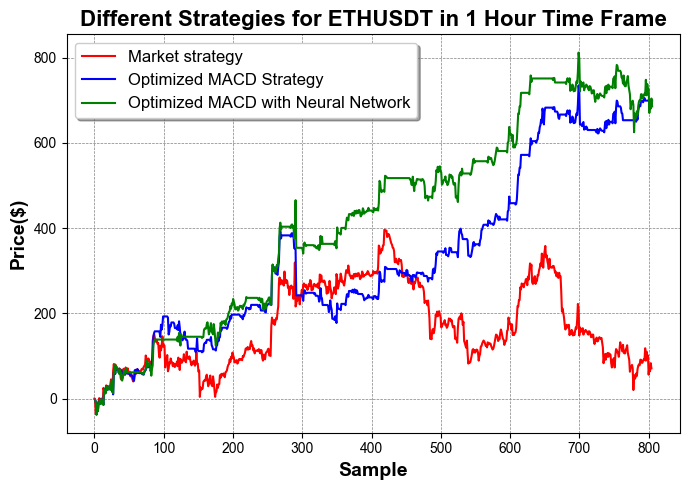

In [32]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fig, axes = plt.subplots(1,1, figsize=(7,5))

t = np.linspace(start=0, stop=len(tot_cum), num=len(tot_cum))

axes.plot(t,trade_df['cumulative_market_return'], color='red', label='Market strategy')
axes.plot(t,tot_cum, color='blue', label='Optimized MACD Strategy')
axes.plot(t,tot_cum_xlstm, color = 'green', label = 'Optimized MACD with Neural Network')

axes.set_xlabel("Sample", fontsize=14, fontweight='bold')
axes.set_ylabel("Price($)", fontsize=14, fontweight='bold')
axes.set_title(f'Different Strategies for {STOCK}USDT in 1 Hour Time Frame', fontsize=16, fontweight='bold')

axes.grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axes.legend(loc='best', fontsize=12, frameon=True, shadow=True, fancybox=True)

axes.spines['right'].set_visible(True)
axes.spines['bottom'].set_visible(True)
axes.spines['left'].set_visible(True)

plt.tight_layout()
plt.savefig(f'strategy/figs/xLSTM_MACD_MARKET_{STOCK}{TF}.png', dpi=300, bbox_inches='tight')
plt.show()